# World Cup 2026 Match Predictor

Predicts the outcome of international World Cup matches (**Team-1 win / Draw / Team-2 win**) from
team-strength features engineered out of 90+ years of World Cup match history, then forecasts the
2026 group-stage fixtures.

**Model:** a 3-class classifier (Logistic Regression baseline + Random Forest). The dataset is tiny
(~960 matches), so training is instantaneous on the Colab free tier — well under the 1–2 hour budget.
The real work is *feature engineering*, not compute.

### Instructions for Shared Users
To run this notebook, add a shortcut to the shared `world_cup_predictor` folder to your Drive:
1. Open the **'Shared with me'** tab in Google Drive.
2. Right-click the `world_cup_predictor` folder → **'Organize'** → **'Add shortcut'**.
3. Choose **'My Drive'** → **'Add'**.

This makes the path `/content/drive/MyDrive/world_cup_predictor/` valid for your account.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, unicodedata
from pathlib import Path
from collections import defaultdict, deque

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, log_loss, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

RANDOM_STATE = 42
pd.set_option('display.max_columns', 60)

## Part 1: Reading the data (Alex)

In [ ]:
# Base directory for the shared project folder
base_path = '/content/drive/MyDrive/world_cup_predictor/'
wc_data_dir = os.path.join(base_path, 'wc_data/')

filepaths = [os.path.join(wc_data_dir, f) for f in os.listdir(wc_data_dir)]

In [ ]:
def convert_to_df(filepath):
    """Read a single .csv into a DataFrame (utf-8, tolerant of stray bytes)."""
    return pd.read_csv(filepath, encoding='utf-8', encoding_errors='replace')

In [ ]:
dfs = {}
for filepath in filepaths:
    dfs[Path(filepath).stem] = convert_to_df(filepath)

In [ ]:
for filename, df in dfs.items():
    print(f'Data Frame for {filename} (first 5 rows):')
    display(df.head(5))
    print(f'Rows in {filename}: {len(df)}\n')

Data Frame for fifa_ranking_2026-06-08 (first 5 rows):


,team,team_code,association,rank,previous_rank,points,previous_points,rated_matches
0,Argentina,ARG,CONMEBOL,1,3,1876.118331,1874.814835,59
1,Spain,ESP,UEFA,2,2,1873.013187,1876.395199,56
2,France,FRA,UEFA,3,1,1869.428449,1877.322731,57
3,England,ENG,UEFA,4,4,1827.048678,1825.965482,57
4,Portugal,POR,UEFA,5,5,1766.177547,1763.834406,56


Rows in fifa_ranking_2026-06-08: 211

Data Frame for schedule_2026 (first 5 rows):


,Round,Day,Date,Time,Score,Referee,Notes,Year,home_team,away_team
0,Group stage,Thu,2026-06-11,13:00 (22:00),NaN,NaN,NaN,2026,Mexico,South Africa
1,Group stage,Thu,2026-06-11,20:00 (05:00),NaN,NaN,NaN,2026,Korea Republic,Czechia
2,Group stage,Fri,2026-06-12,15:00 (22:00),NaN,NaN,NaN,2026,Canada,Bosnia-Herzegovina
3,Group stage,Fri,2026-06-12,18:00 (04:00),NaN,NaN,NaN,2026,United States,Paraguay
4,Group stage,Sat,2026-06-13,12:00 (22:00),NaN,NaN,NaN,2026,Qatar,Switzerland


Rows in schedule_2026: 72

Data Frame for fifa_ranking_2022-10-06 (first 5 rows):


...

Rows in fifa_ranking_2022-10-06: 211

Data Frame for matches_1930_2022 (first 5 rows):


,home_team,away_team,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,home_manager,home_captain,away_manager,away_captain,Attendance,Venue,Officials,Round,Date,Score,Referee,Notes,Host,Year,home_goal,away_goal,home_goal_long,away_goal_long,home_own_goal,away_own_goal,home_penalty_goal,away_penalty_goal,home_penalty_miss_long,away_penalty_miss_long,home_penalty_shootout_goal_long,away_penalty_shootout_goal_long,home_penalty_shootout_miss_long,away_penalty_shootout_miss_long,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long
0,Argentina,France,3,3.3,4.0,3,2.2,2.0,Lionel Scaloni,Lionel Messi,Didier Deschamps,Hugo Lloris,88966,"Lusail Iconic Stadium, Lusail",Szymon Marciniak (Referee) · Paweł Sokolnicki ...,Final,2022-12-18,(4) 3–3 (2),Szymon Marciniak,Argentina won on penalty kicks following extra...,Qatar,2022,Ángel Di María · 36|Lionel Messi · 108,Kylian Mbappé · 81,['36&rsquor;|2:0|Ángel Di María|Assist:|Alexis...,['81&rsquor;|2:2|Kylian Mbappé|Assist:|Marcus ...,NaN,NaN,Lionel Messi (P) · 23,Kylian Mbappé (P) · 80|Kylian Mbappé (P) · 118,NaN,NaN,"['2|1:1|Lionel Messi', '4|2:1|Paulo Dybala', '...","['1|0:1|Kylian Mbappé', '7|3:2|Randal Kolo Mua...",NaN,"['3|1:1|Kingsley Coman', '5|2:1|Aurélien Tchou...",NaN,NaN,NaN,NaN,"['45+7&rsquor;|2:0|Enzo Fernández', '90+8&rsqu...","['55&rsquor;|2:0|Adrien Rabiot', '87&rsquor;|2...",['64&rsquor;|2:0|Marcos Acuña|for Ángel Di Mar...,['41&rsquor;|2:0|Randal Kolo Muani|for Ousmane...
1,Croatia,Morocco,2,0.7,NaN,1,1.2,NaN,Zlatko Dalić,Luka Modrić,Hoalid Regragui,Hakim Ziyech,44137,"Khalifa International Stadium, Doha",Abdulrahman Ibrahim Al Jassim (Referee) · Tale...,Third-place match,2022-12-17,2–1,Abdulrahman Ibrahim Al Jassim,NaN,Qatar,2022,Joško Gvardiol · 7|Mislav Oršić · 42,Achraf Dari · 9,['7&rsquor;|1:0|Joško Gvardiol|Assist:|Ivan Pe...,['9&rsquor;|1:1|Achraf Dari'],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['69&rsquor;|2:1|Azzedine Ounahi', '84&rsquor;...",['61&rsquor;|2:1|Nikola Vlašić|for Andrej Kram...,['46&rsquor;|2:1|Ilias Chair|for Abdelhamid Sa...
2,France,Morocco,2,2.0,NaN,0,0.9,NaN,Didier Deschamps,Hugo Lloris,Hoalid Regragui,Romain Saïss,68294,"Al Bayt Stadium, Al Khor",César Arturo Ramos (Referee) · Alberto Morín (...,Semi-finals,2022-12-14,2–0,César Arturo Ramos,NaN,Qatar,2022,Theo Hernández · 5|Randal Kolo Muani · 79,NaN,"['5&rsquor;|1:0|Theo Hernández', '79&rsquor;|2...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['27&rsquor;|1:0|Sofiane Boufal'],['65&rsquor;|1:0|Marcus Thuram|for Olivier Gir...,['21&rsquor;|1:0|Selim Amallah|for Romain Saïs...
3,Argentina,Croatia,3,2.3,NaN,0,0.5,NaN,Lionel Scaloni,Lionel Messi,Zlatko Dalić,Luka Modrić,88966,"Lusail Iconic Stadium, Lusail",Daniele Orsato (Referee) · Ciro Carbone (AR1) ...,Semi-finals,2022-12-13,3–0,Daniele Orsato,NaN,Qatar,2022,Julián Álvarez · 39|Julián Álvarez · 69,NaN,"['39&rsquor;|2:0|Julián Álvarez', '69&rsquor;|...",NaN,NaN,NaN,Lionel Messi (P) · 34,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['68&rsquor;|2:0|Cristian Romero', '71&rsquor;...","['32&rsquor;|0:0|Mateo Kovačić', '32&rsquor;|0...",['62&rsquor;|2:0|Lisandro Martínez|for Leandro...,"['46&rsquor;|2:0|Mislav Oršić|for Borna Sosa',..."
4,Morocco,Portugal,1,1.4,NaN,0,0.9,NaN,Hoalid Regragui,Romain Saïss,Fernando Santos,Pepe,44198,"Al Thumama Stadium, ath-Thumāma",Facundo Tello (Referee) · Ezequiel Brailovsky ...,Quarter-finals,2022-12-10,1–0,Facundo Tello,NaN,Qatar,2022,Youssef En-Nesyri · 42,NaN,['42&rsquor;|1:0|Youssef En-Nesyri|Assist:|Yah...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Walid Cheddira · 90+3,NaN,"['70&rsquor;|1:0|Achraf Dari', '90+1&rsquor;|1...",['87&rsquor;|1:0|Vitinha'],['57&rsquor;|1:0|Achraf Dari|for Romain Saïss'...,['51&rsquor;|1:0|João Cancelo|for Raphaël Guer...


Rows in matches_1930_2022: 964

Data Frame for world_cup (first 5 rows):


,Year,Host,Teams,Champion,Runner-Up,TopScorrer,Attendance,AttendanceAvg,Matches
0,2022,Qatar,32,Argentina,France,Kylian Mbappé - 8,3404252,53191,64
1,2018,Russia,32,France,Croatia,Harry Kane - 6,3031768,47371,64
2,2014,Brazil,32,Germany,Argentina,James Rodríguez - 6,3429873,53592,64
3,2010,South Africa,32,Spain,Netherlands,"Wesley Sneijder, Thomas Müller... - 5",3178856,49670,64
4,2006,Germany,32,Italy,France,Miroslav Klose - 5,3352605,52384,64


Rows in world_cup: 22



In [ ]:
# Grab the tables we need by name
matches   = dfs['matches_1930_2022'].copy()
rank_2026 = dfs['fifa_ranking_2026-06-08'].copy()
schedule  = dfs['schedule_2026'].copy()
print('matches:', matches.shape, '| rank_2026:', rank_2026.shape, '| schedule:', schedule.shape)

matches: (964, 44) | rank_2026: (211, 8) | schedule: (72, 10)


## Part 2: Feature engineering & train-test split (David)

### 2.1 Clean matches and define the target label
The target is the match result from the **first-listed team's** perspective:
`H` (team-1 win), `D` (draw), or `A` (team-2 win), based on the 90-minute (regulation) score.
Penalty-shootout winners are treated as draws — they *were* draws in regulation.

In [ ]:
m = matches.dropna(subset=['home_score', 'away_score']).copy()
m['home_score'] = m['home_score'].astype(int)
m['away_score'] = m['away_score'].astype(int)
m = m.sort_values('Date').reset_index(drop=True)   # chronological order matters for Elo

def result(hs, a):
    return 'H' if hs > a else ('A' if hs < a else 'D')
m['res'] = [result(h, a) for h, a in zip(m.home_score, m.away_score)]

print('Matches with a final score:', len(m))
print(m['res'].value_counts(normalize=True).round(3).to_dict())

Matches with a final score: 964
{'H': 0.552, 'A': 0.226, 'D': 0.222}


### 2.2 Elo ratings (the core strength feature)

FIFA rankings only exist as 2022 / 2026 snapshots, so we can't attach a *contemporaneous* ranking to a
1954 match. Instead we compute an **Elo rating** that walks through match history in date order and updates
each team after every game. This is leakage-free: the rating used for a match reflects only games played
*before* it. We use a goal-difference multiplier so blowouts move ratings more.

In [ ]:
BASE_ELO, K = 1500.0, 40.0
elo = defaultdict(lambda: BASE_ELO)
home_elo, away_elo = [], []

for _, row in m.iterrows():
    h, a = row.home_team, row.away_team
    eh, ea = elo[h], elo[a]
    home_elo.append(eh); away_elo.append(ea)         # pre-match ratings = the feature
    exp_h = 1.0 / (1.0 + 10 ** ((ea - eh) / 400.0))  # expected score for team-1
    s_h = 1.0 if row.res == 'H' else (0.5 if row.res == 'D' else 0.0)
    gd_mult = np.log(abs(row.home_score - row.away_score) + 1) + 1  # >=1, grows with margin
    delta = K * gd_mult * (s_h - exp_h)
    elo[h] = eh + delta
    elo[a] = ea - delta

m['home_elo'], m['away_elo'] = home_elo, away_elo
print('Top 10 all-time World Cup Elo:')
for t, v in sorted(elo.items(), key=lambda x: -x[1])[:10]:
    print(f'  {t:<15} {v:6.0f}')

Top 10 all-time World Cup Elo:
  Netherlands       1879
  France            1833
  West Germany      1786
  Germany           1765
  Argentina         1747
  Brazil            1731
  Belgium           1671
  England           1660
  Italy             1649
  Spain             1648


### 2.3 Rolling form features (also causal)
For each match we also record, using only prior games:
- **form** = average goal difference over the team's last 5 matches
- **winrate** = share of matches won so far (draws count as ½)

In [ ]:
last5   = defaultdict(lambda: deque(maxlen=5))
wins    = defaultdict(float)
played  = defaultdict(int)
h_form, a_form, h_wr, a_wr = [], [], [], []

for _, row in m.iterrows():
    h, a = row.home_team, row.away_team
    h_form.append(np.mean(last5[h]) if last5[h] else 0.0)
    a_form.append(np.mean(last5[a]) if last5[a] else 0.0)
    h_wr.append(wins[h] / played[h] if played[h] else 0.5)
    a_wr.append(wins[a] / played[a] if played[a] else 0.5)
    gd = row.home_score - row.away_score
    last5[h].append(gd); last5[a].append(-gd)
    played[h] += 1; played[a] += 1
    if   row.res == 'H': wins[h] += 1
    elif row.res == 'A': wins[a] += 1
    else:                wins[h] += 0.5; wins[a] += 0.5

m['h_form'], m['a_form'] = h_form, a_form
m['h_wr'],   m['a_wr']   = h_wr, a_wr

# Snapshot each team's FINAL state - reused for 2026 forecasting in Part 4
final_form = {t: (np.mean(v) if v else 0.0) for t, v in last5.items()}
final_wr   = {t: (wins[t] / played[t] if played[t] else 0.5) for t in played}

### 2.4 Build a symmetric feature matrix
All features are **differences** (team-1 minus team-2). To remove any bias from which team happens to be
listed first, every match is added **twice**: once as-is and once mirrored (teams swapped, diffs negated,
label flipped H↔A). We split matches into train/test *first*, then expand each side, so the two views of a
match never straddle the split (no leakage).

Feature columns: `elo_diff`, `form_diff`, `wr_diff`.

In [ ]:
FEATURES = ['elo_diff', 'form_diff', 'wr_diff']
LABELS   = {'A': 0, 'D': 1, 'H': 2}   # ordered: team-2 win < draw < team-1 win

def expand(df):
    """Return (X, y) with each match represented from both perspectives."""
    straight = pd.DataFrame({
        'elo_diff':  df.home_elo - df.away_elo,
        'form_diff': df.h_form   - df.a_form,
        'wr_diff':   df.h_wr     - df.a_wr,
    })
    y_s = df.res.map(LABELS)
    mirror = pd.DataFrame({
        'elo_diff':  df.away_elo - df.home_elo,
        'form_diff': df.a_form   - df.h_form,
        'wr_diff':   df.a_wr     - df.h_wr,
    })
    y_m = df.res.map({'H': 0, 'D': 1, 'A': 2})   # flipped
    X = pd.concat([straight, mirror], ignore_index=True)
    y = pd.concat([y_s, y_m], ignore_index=True)
    return X, y

# Split MATCHES (stratified on result), then expand each side
train_m, test_m = train_test_split(m, test_size=0.2, random_state=RANDOM_STATE, stratify=m.res)
X_train, y_train = expand(train_m)
X_test,  y_test  = expand(test_m)
print('train:', X_train.shape, '| test:', X_test.shape)
print('train label balance:', y_train.value_counts(normalize=True).round(3).to_dict())

train: (1542, 3) | test: (386, 3)
train label balance: {2: 0.389, 0: 0.389, 1: 0.222}


## Part 3: Model training & evaluation (Aashna)

Two lightweight classifiers, both train in well under a second:
- **Logistic Regression** (standardized) — interpretable linear baseline.
- **Random Forest** — captures non-linear interactions; our primary model.

We compare against a **majority-class baseline** (always predict the most common label).

In [ ]:
# class_weight='balanced' up-weights the minority class (draws), which the model
# otherwise almost never predicts.
logreg = make_pipeline(StandardScaler(),
                       LogisticRegression(max_iter=1000, class_weight='balanced',
                                          random_state=RANDOM_STATE))
rf = RandomForestClassifier(n_estimators=300, max_depth=6, class_weight='balanced',
                            random_state=RANDOM_STATE, n_jobs=-1)

logreg.fit(X_train, y_train)
rf.fit(X_train, y_train)

target_names = ['Team-2 win (A)', 'Draw (D)', 'Team-1 win (H)']
majority = y_train.value_counts().idxmax()

def evaluate(name, model):
    pred  = model.predict(X_test)
    proba = model.predict_proba(X_test)
    print(f'=== {name} ===')
    print(f'  accuracy : {accuracy_score(y_test, pred):.3f}')
    print(f'  macro-F1 : {f1_score(y_test, pred, average="macro"):.3f}')
    print(f'  log-loss : {log_loss(y_test, proba):.3f}')
    return pred

print(f'Majority-class baseline accuracy: {(y_test == majority).mean():.3f}\n')
pred_lr = evaluate('Logistic Regression', logreg)
print()
pred_rf = evaluate('Random Forest', rf)

Majority-class baseline accuracy: 0.389

=== Logistic Regression ===
  accuracy : 0.456
  macro-F1 : 0.416
  log-loss : 1.063

=== Random Forest ===
  accuracy : 0.479
  macro-F1 : 0.407
  log-loss : 1.032


                precision    recall  f1-score   support

Team-2 win (A)       0.51      0.59      0.55       150
      Draw (D)       0.21      0.09      0.13        86
Team-1 win (H)       0.51      0.59      0.54       150

      accuracy                           0.48       386
     macro avg       0.41      0.42      0.41       386
  weighted avg       0.44      0.48      0.45       386



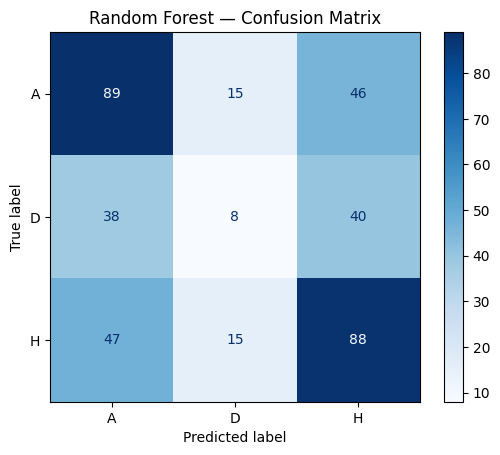

In [ ]:
# Confusion matrix + full report for the Random Forest
print(classification_report(y_test, pred_rf, target_names=target_names))
cm = confusion_matrix(y_test, pred_rf)
ConfusionMatrixDisplay(cm, display_labels=['A', 'D', 'H']).plot(cmap='Blues')
plt.title('Random Forest — Confusion Matrix'); plt.show()

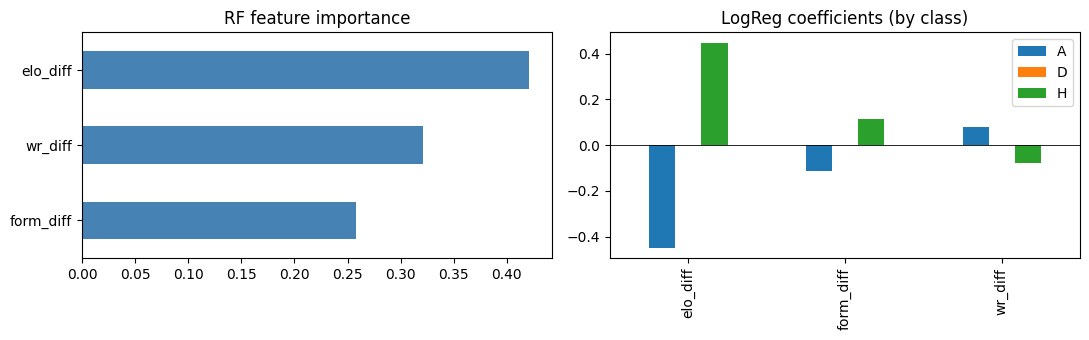

In [ ]:
# Feature importance (Random Forest) and logistic coefficients
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
pd.Series(rf.feature_importances_, index=FEATURES).sort_values().plot.barh(
    ax=ax[0], color='steelblue'); ax[0].set_title('RF feature importance')
coefs = logreg.named_steps['logisticregression'].coef_
pd.DataFrame(coefs, columns=FEATURES, index=['A', 'D', 'H']).T.plot.bar(ax=ax[1])
ax[1].set_title('LogReg coefficients (by class)'); ax[1].axhline(0, color='k', lw=.6)
plt.tight_layout(); plt.show()

## Part 4: Forecasting the 2026 World Cup

To score a 2026 fixture we need each team's `elo_diff / form_diff / wr_diff`. We reuse each team's **final**
Elo / form / win-rate from Part 2. The 2026 field has 48 teams, and a few (e.g. Cabo Verde) have little or no
World Cup history — for those we **bridge** from their current FIFA ranking points using a linear map fitted
on teams that have *both* an Elo and a 2026 ranking. Team names differ across files, so we normalize them first.

In [ ]:
def strip_accents(s):
    s = str(s)
    return ''.join(c for c in unicodedata.normalize('NFKD', s) if not unicodedata.combining(c))

def norm(s):
    return strip_accents(s).lower().strip()

# Manual map: 2026 spelling -> spelling used in match history / ranking
NAME_MAP = {
    'Bosnia-Herzegovina': 'Bosnia and Herzegovina', 'Cape Verde': 'Cabo Verde',
    'Czechia': 'Czech Republic', 'Korea Republic': 'South Korea', 'IR Iran': 'Iran',
    'Türkiye': 'Turkey', "Côte d'Ivoire": 'Ivory Coast', 'Curaçao': 'Curacao',
}

# Accent-insensitive lookup tables
elo_by_norm   = {norm(k): v for k, v in elo.items()}
form_by_norm  = {norm(k): v for k, v in final_form.items()}
wr_by_norm    = {norm(k): v for k, v in final_wr.items()}
pts_by_norm   = {norm(t): p for t, p in zip(rank_2026.team, rank_2026.points)}

In [ ]:
# Fit the FIFA-points -> Elo bridge on teams that have both
both = [(pts_by_norm[n], elo_by_norm[n]) for n in pts_by_norm if n in elo_by_norm]
pts_arr, elo_arr = np.array(both).T
b1, b0 = np.polyfit(pts_arr, elo_arr, 1)
print(f'Bridge:  Elo ~= {b0:.1f} + {b1:.3f} * FIFA_points   (n={len(both)}, '
      f'corr={np.corrcoef(pts_arr, elo_arr)[0,1]:.2f})')

def resolve(name):
    """Best available name key for a 2026 team (mapped -> raw), accent-insensitive."""
    for cand in (NAME_MAP.get(name, name), name):
        if norm(cand) in elo_by_norm or norm(cand) in pts_by_norm:
            return norm(cand)
    return norm(name)

def team_feats(name):
    key = resolve(name)
    if key in elo_by_norm:
        return elo_by_norm[key], form_by_norm.get(key, 0.0), wr_by_norm.get(key, 0.5)
    if key in pts_by_norm:                 # no WC history -> bridge from FIFA points
        return b0 + b1 * pts_by_norm[key], 0.0, 0.5
    return 1400.0, 0.0, 0.5                 # last-resort weak prior

Bridge:  Elo ~= 845.0 + 0.432 * FIFA_points   (n=75, corr=0.69)


In [ ]:
# Sanity check: assign a strength to every scheduled 2026 team
sched_teams = sorted(set(schedule.home_team) | set(schedule.away_team))
strength = {t: team_feats(t) for t in sched_teams}
print(f'2026 teams resolved: {len(sched_teams)}')
rank_tbl = pd.DataFrame(
    [(t, e, f, w) for t, (e, f, w) in strength.items()],
    columns=['team', 'elo', 'form', 'winrate']).sort_values('elo', ascending=False)
display(rank_tbl.head(10).reset_index(drop=True))

2026 teams resolved: 48


,team,elo,form,winrate
0,Netherlands,1879.318738,1.2,0.672727
1,France,1832.944746,0.8,0.630137
2,Germany,1764.765510,0.0,0.723214
3,Argentina,1747.294451,1.2,0.630682
4,Brazil,1730.548619,1.0,0.750000
5,Belgium,1670.704068,0.0,0.509804
6,England,1659.865841,1.8,0.581081
7,Spain,1647.661859,1.2,0.589552
8,Croatia,1647.636468,-0.4,0.566667
9,Sweden,1623.090362,0.4,0.500000


In [ ]:
# Predict every 2026 group-stage fixture with the Random Forest
def predict_match(home, away, model=rf):
    eh, fh, wh = team_feats(home)
    ea, fa, wa = team_feats(away)
    x = pd.DataFrame([[eh - ea, fh - fa, wh - wa]], columns=FEATURES)
    p = model.predict_proba(x)[0]           # [P(A/away win), P(draw), P(H/home win)]
    return p[2], p[1], p[0]

rows = []
for _, g in schedule.iterrows():
    ph, pd_, pa = predict_match(g.home_team, g.away_team)
    outcome = max([(ph, f'{g.home_team} win'), (pd_, 'Draw'), (pa, f'{g.away_team} win')])[1]
    rows.append([g.home_team, g.away_team, round(ph, 3), round(pd_, 3), round(pa, 3), outcome])

preds_2026 = pd.DataFrame(rows, columns=['home', 'away', 'P(home)', 'P(draw)', 'P(away)', 'prediction'])
print(f'Predicted {len(preds_2026)} group-stage matches')
display(preds_2026.head(20))

Predicted 72 group-stage matches


,home,away,P(home),P(draw),P(away),prediction
0,Mexico,South Africa,0.436,0.256,0.308,Mexico win
1,Korea Republic,Czechia,0.380,0.273,0.347,Korea Republic win
2,Canada,Bosnia-Herzegovina,0.214,0.439,0.348,Draw
3,United States,Paraguay,0.226,0.350,0.423,Paraguay win
4,Qatar,Switzerland,0.214,0.450,0.336,Draw
5,Brazil,Morocco,0.480,0.345,0.174,Brazil win
6,Haiti,Scotland,0.210,0.387,0.403,Scotland win
7,Australia,Türkiye,0.187,0.467,0.346,Draw
8,Germany,Curaçao,0.541,0.331,0.128,Germany win
9,Netherlands,Japan,0.549,0.303,0.148,Netherlands win


In [ ]:
# Optional: save predictions back to Drive
out_path = os.path.join(base_path, 'predictions_2026_group_stage.csv')
preds_2026.to_csv(out_path, index=False)
print('Saved ->', out_path)

Saved -> /content/drive/MyDrive/world_cup_predictor/predictions_2026_group_stage.csv


## Discussion & limitations

- **~0.52 accuracy on 3 classes vs ~0.39 majority baseline** — a real, if modest, lift. Football is
  high-variance and draws are genuinely hard to call, so this is in line with published match-outcome models.
- **Draw recall is the weak spot** (see the confusion matrix) — common for this task.
- The 2026 Elo bridge for history-less teams is approximate (FIFA-points correlation ≈ 0.7).
- **Possible extensions:** predict scorelines with a Poisson/bivariate-Poisson model to simulate the whole
  bracket; add rest days, confederation, and host-advantage features; calibrate probabilities; a chronological
  (train-on-past / test-on-future) split for a stricter forecasting evaluation.

**Sources:**

*Part 1:* https://www.geeksforgeeks.org/python/os-module-python-examples/ ,
https://www.geeksforgeeks.org/python/python-program-to-get-the-file-name-from-the-file-path/

*Part 2 (Elo):* Elo rating system — https://en.wikipedia.org/wiki/Elo_rating_system ;
World Football Elo Ratings — https://www.eloratings.net/about

*Parts 3–4 (scikit-learn):* https://scikit-learn.org/stable/supervised_learning.html

*Overall:* Code reference — https://www.kaggle.com/code/ahmedwaleed1903/world-cup ;
Data — https://www.kaggle.com/datasets/piterfm/fifa-football-world-cup

**AI Usage**

Google Gemini (Gemini 3 Flash) was used to write and debug some specific lines/blocks of code in the notebook.
Anthropic Claude (Opus 4.8) assisted with the feature-engineering design (Elo + rolling form), the
model/eval pipeline, and the 2026 forecasting bridge.